In [3]:
import pandas as pd

df = pd.read_csv("/content/dermatology_database_1.csv")


print("Shape of dataset:", df.shape)

print("Columns:")
print(df.columns)

Shape of dataset: (366, 35)
Columns:
Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_infiltrate', 'PNL_infiltrate', 'fibrosis_papillary_dermis',
       'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis',
       'clubbing_rete_ridges', 'elongation_rete_ridges',
       'thinning_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_granular_layer', 'vacuolisation_damage_basal_layer',
       'spongiosis', 'saw_tooth_appearance_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_mononuclear_infiltrate',
       'band_like_infiltrate', 'age', 'class'],
      dtype='object')


In [4]:
print(df.describe())

         erythema     scaling  definite_borders     itching  \
count  366.000000  366.000000        366.000000  366.000000   
mean     2.068306    1.795082          1.549180    1.366120   
std      0.664753    0.701527          0.907525    1.138299   
min      0.000000    0.000000          0.000000    0.000000   
25%      2.000000    1.000000          1.000000    0.000000   
50%      2.000000    2.000000          2.000000    1.000000   
75%      2.000000    2.000000          2.000000    2.000000   
max      3.000000    3.000000          3.000000    3.000000   

       koebner_phenomenon  polygonal_papules  follicular_papules  \
count          366.000000         366.000000          366.000000   
mean             0.633880           0.448087            0.166667   
std              0.908016           0.957327            0.570588   
min              0.000000           0.000000            0.000000   
25%              0.000000           0.000000            0.000000   
50%              0.00000

In [5]:
print(df.isnull().sum())

erythema                               0
scaling                                0
definite_borders                       0
itching                                0
koebner_phenomenon                     0
polygonal_papules                      0
follicular_papules                     0
oral_mucosal_involvement               0
knee_and_elbow_involvement             0
scalp_involvement                      0
family_history                         0
melanin_incontinence                   0
eosinophils_infiltrate                 0
PNL_infiltrate                         0
fibrosis_papillary_dermis              0
exocytosis                             0
acanthosis                             0
hyperkeratosis                         0
parakeratosis                          0
clubbing_rete_ridges                   0
elongation_rete_ridges                 0
thinning_suprapapillary_epidermis      0
spongiform_pustule                     0
munro_microabcess                      0
focal_hypergranu

In [6]:
print(df.duplicated().sum())

0


In [7]:
import numpy as np

numeric_columns = df.select_dtypes(include=['number']).columns

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(column, ":", len(outliers), "outliers")

erythema : 151 outliers
scaling : 0 outliers
definite_borders : 0 outliers
itching : 0 outliers
koebner_phenomenon : 18 outliers
polygonal_papules : 69 outliers
follicular_papules : 33 outliers
oral_mucosal_involvement : 67 outliers
knee_and_elbow_involvement : 23 outliers
scalp_involvement : 16 outliers
family_history : 46 outliers
melanin_incontinence : 70 outliers
eosinophils_infiltrate : 42 outliers
PNL_infiltrate : 7 outliers
fibrosis_papillary_dermis : 54 outliers
exocytosis : 0 outliers
acanthosis : 156 outliers
hyperkeratosis : 5 outliers
parakeratosis : 0 outliers
clubbing_rete_ridges : 0 outliers
elongation_rete_ridges : 0 outliers
thinning_suprapapillary_epidermis : 31 outliers
spongiform_pustule : 70 outliers
munro_microabcess : 80 outliers
focal_hypergranulosis : 71 outliers
disappearance_granular_layer : 14 outliers
vacuolisation_damage_basal_layer : 72 outliers
spongiosis : 0 outliers
saw_tooth_appearance_retes : 72 outliers
follicular_horn_plug : 22 outliers
perifollicu

In [9]:
import pandas as pd
import numpy as np

df_clean = df.copy()

numeric_columns = df_clean.select_dtypes(include=['number']).columns

numeric_features = numeric_columns.drop('class')

for column in numeric_features:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean[column] = np.where(
        df_clean[column] < lower_limit,
        lower_limit,
        df_clean[column]
    )

    df_clean[column] = np.where(
        df_clean[column] > upper_limit,
        upper_limit,
        df_clean[column]
    )

    print(column, ":", len(outliers), "outliers")

erythema : 0 outliers
scaling : 0 outliers
definite_borders : 0 outliers
itching : 0 outliers
koebner_phenomenon : 0 outliers
polygonal_papules : 0 outliers
follicular_papules : 0 outliers
oral_mucosal_involvement : 0 outliers
knee_and_elbow_involvement : 0 outliers
scalp_involvement : 0 outliers
family_history : 0 outliers
melanin_incontinence : 0 outliers
eosinophils_infiltrate : 0 outliers
PNL_infiltrate : 0 outliers
fibrosis_papillary_dermis : 0 outliers
exocytosis : 0 outliers
acanthosis : 0 outliers
hyperkeratosis : 0 outliers
parakeratosis : 0 outliers
clubbing_rete_ridges : 0 outliers
elongation_rete_ridges : 0 outliers
thinning_suprapapillary_epidermis : 0 outliers
spongiform_pustule : 0 outliers
munro_microabcess : 0 outliers
focal_hypergranulosis : 0 outliers
disappearance_granular_layer : 0 outliers
vacuolisation_damage_basal_layer : 0 outliers
spongiosis : 0 outliers
saw_tooth_appearance_retes : 0 outliers
follicular_horn_plug : 0 outliers
perifollicular_parakeratosis : 0 

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_features = df_clean.select_dtypes(
    include=['number']
).columns.drop('class')

print("Number of features:", len(numeric_features))
print(numeric_features)

Number of features: 33
Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_infiltrate', 'PNL_infiltrate', 'fibrosis_papillary_dermis',
       'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis',
       'clubbing_rete_ridges', 'elongation_rete_ridges',
       'thinning_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_granular_layer', 'vacuolisation_damage_basal_layer',
       'spongiosis', 'saw_tooth_appearance_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_mononuclear_infiltrate',
       'band_like_infiltrate'],
      dtype='object')


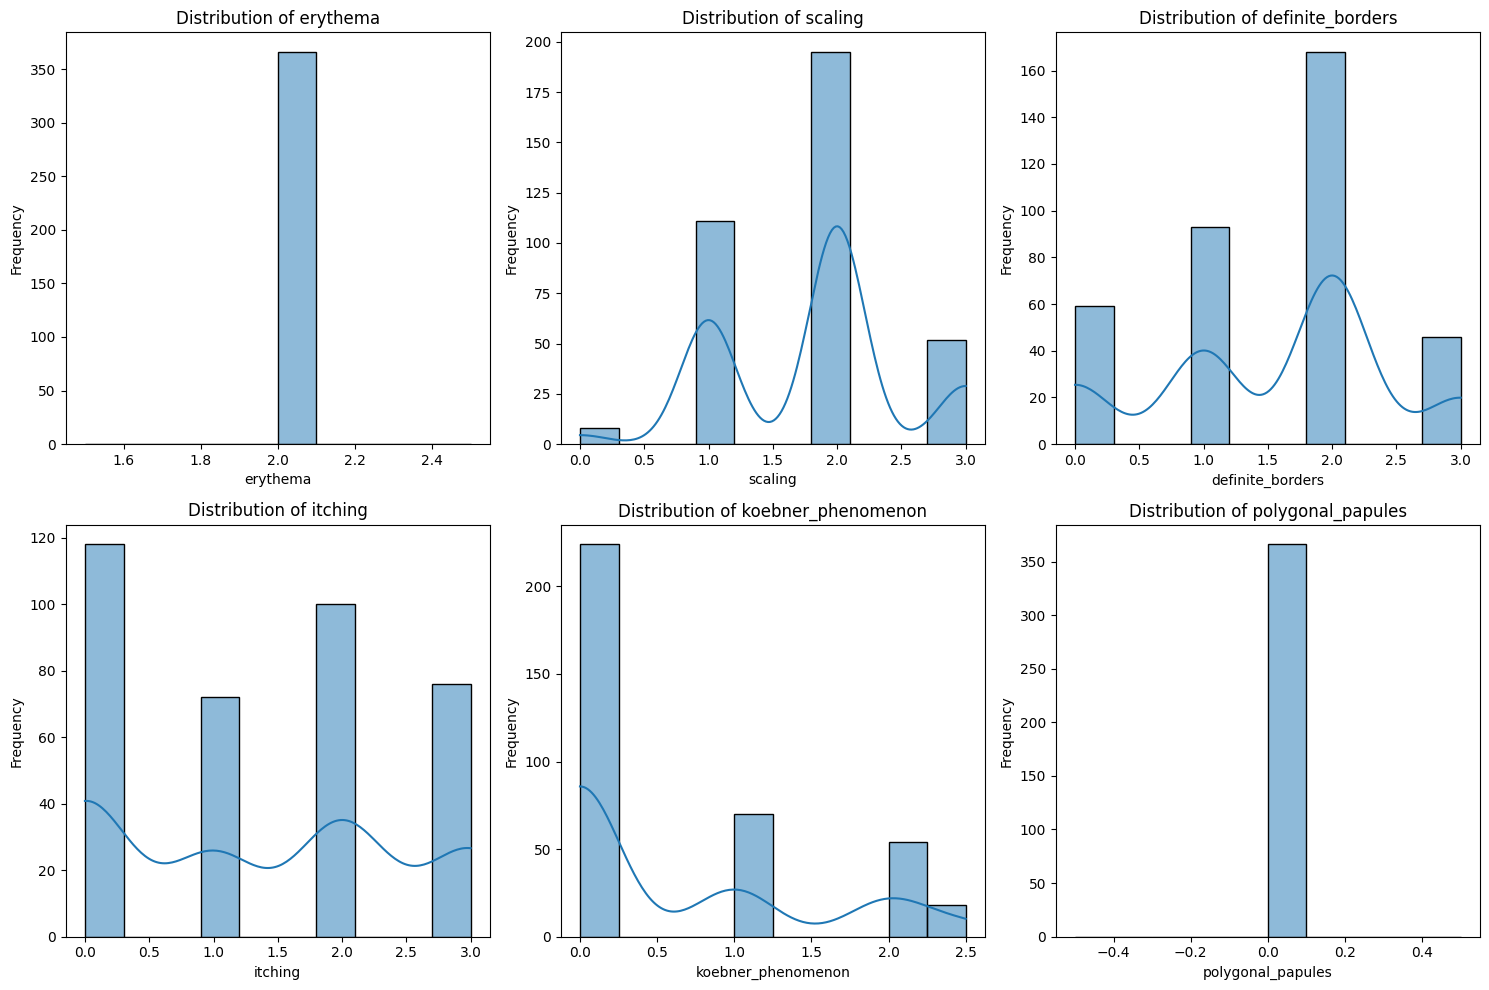

In [11]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(numeric_features[:6], 1):

    plt.subplot(2, 3, i)

    sns.histplot(
        data=df_clean,
        x=column,
        bins=10,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

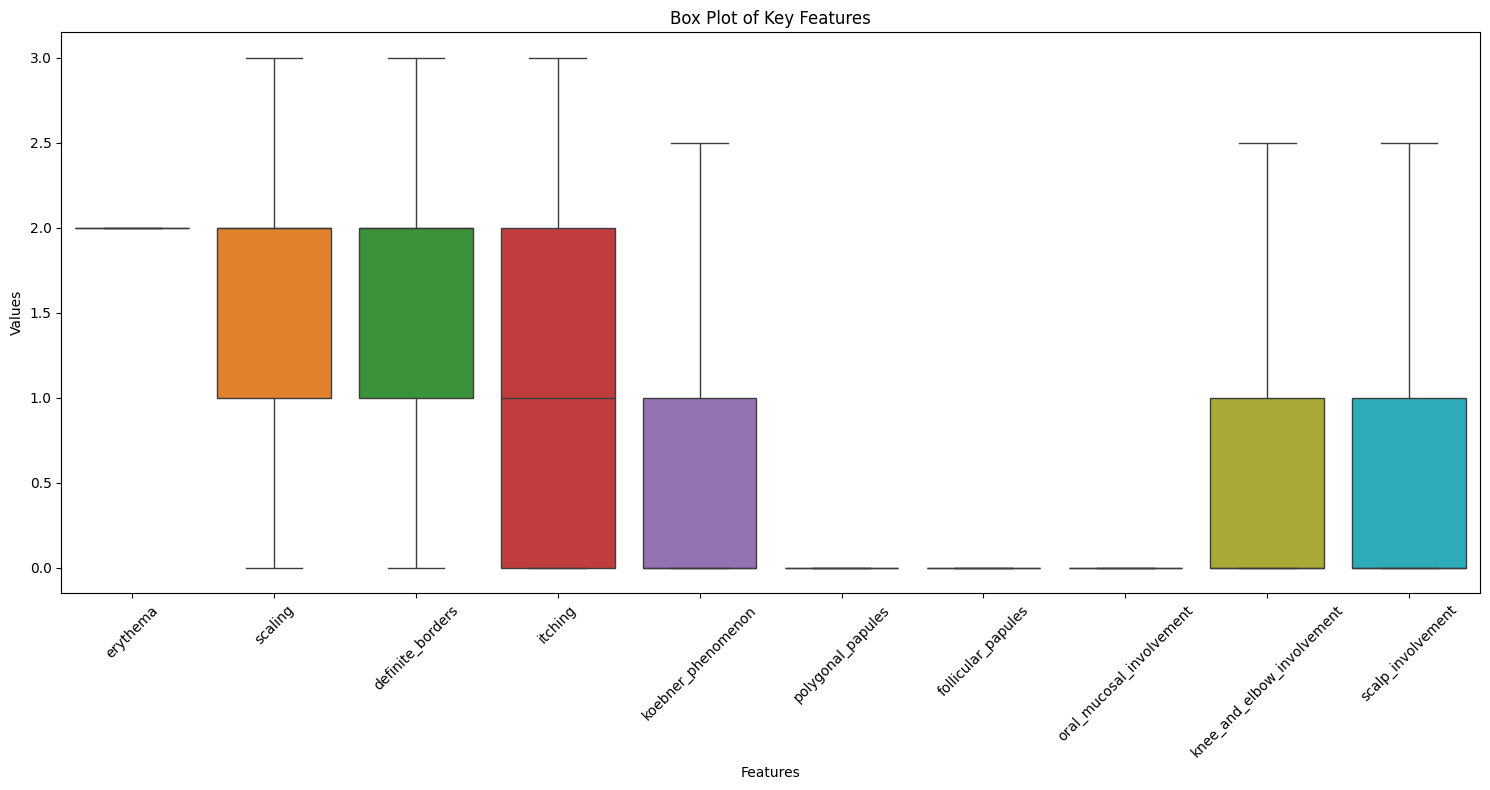

In [12]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df_clean[numeric_features[:10]]
)

plt.title("Box Plot of Key Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
print("Class Distribution:")
print(df_clean['class'].value_counts().sort_index())

print("\nClass Distribution in Percentage:")
print(
    df_clean['class']
    .value_counts(normalize=True)
    .sort_index() * 100
)

Class Distribution:
class
1    112
2     61
3     72
4     49
5     52
6     20
Name: count, dtype: int64

Class Distribution in Percentage:
class
1    30.601093
2    16.666667
3    19.672131
4    13.387978
5    14.207650
6     5.464481
Name: proportion, dtype: float64


In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_clean['class'] = encoder.fit_transform(df_clean['class'])

print("Encoded classes:")
print(df_clean['class'].unique())

print("\nClass mapping:")
for original, encoded in zip(encoder.classes_, encoder.transform(encoder.classes_)):
    print(original, "->", encoded)

Encoded classes:
[1 0 2 4 3 5]

Class mapping:
1 -> 0
2 -> 1
3 -> 2
4 -> 3
5 -> 4
6 -> 5


In [15]:
X = df_clean.drop('class', axis=1)

y = df_clean['class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (366, 34)
Target shape: (366,)


In [23]:
# Check data types of X_train
print(X_train.dtypes)

erythema                               float64
scaling                                float64
definite_borders                       float64
itching                                float64
koebner_phenomenon                     float64
polygonal_papules                      float64
follicular_papules                     float64
oral_mucosal_involvement               float64
knee_and_elbow_involvement             float64
scalp_involvement                      float64
family_history                         float64
melanin_incontinence                   float64
eosinophils_infiltrate                 float64
PNL_infiltrate                         float64
fibrosis_papillary_dermis              float64
exocytosis                             float64
acanthosis                             float64
hyperkeratosis                         float64
parakeratosis                          float64
clubbing_rete_ridges                   float64
elongation_rete_ridges                 float64
thinning_supr

In [24]:
for column in X_train.columns:
    if X_train[column].astype(str).str.contains(r'\?', regex=True).any():
        print("Column containing ?: ", column)

Column containing ?:  age


In [25]:
print((X_train.astype(str) == '?').sum())

erythema                               0
scaling                                0
definite_borders                       0
itching                                0
koebner_phenomenon                     0
polygonal_papules                      0
follicular_papules                     0
oral_mucosal_involvement               0
knee_and_elbow_involvement             0
scalp_involvement                      0
family_history                         0
melanin_incontinence                   0
eosinophils_infiltrate                 0
PNL_infiltrate                         0
fibrosis_papillary_dermis              0
exocytosis                             0
acanthosis                             0
hyperkeratosis                         0
parakeratosis                          0
clubbing_rete_ridges                   0
elongation_rete_ridges                 0
thinning_suprapapillary_epidermis      0
spongiform_pustule                     0
munro_microabcess                      0
focal_hypergranu

In [26]:
X = X.apply(pd.to_numeric, errors='coerce')

print(X.isnull().sum().sum())

8


In [29]:
print(df_clean.loc[X[X['age'].isnull()].index, 'age'])

33     ?
34     ?
35     ?
36     ?
262    ?
263    ?
264    ?
265    ?
Name: age, dtype: object


In [30]:
print(df_clean['age'].unique())

['55' '8' '26' '40' '45' '41' '18' '57' '22' '30' '20' '21' '10' '65' '38'
 '23' '17' '51' '42' '44' '33' '43' '50' '34' '?' '15' '46' '62' '35' '48'
 '12' '52' '60' '32' '19' '29' '25' '36' '13' '27' '31' '28' '64' '39'
 '47' '16' '0' '7' '70' '37' '61' '67' '56' '53' '24' '58' '49' '63' '68'
 '9' '75']


In [33]:
import numpy as np
import pandas as pd

df_clean['age'] = df_clean['age'].replace('?', np.nan)

df_clean['age'] = pd.to_numeric(df_clean['age'], errors='coerce')

median_age = df_clean['age'].median()

df_clean['age'] = df_clean['age'].fillna(median_age)

print("Median age:", median_age)
print("Missing values in age:", df_clean['age'].isnull().sum())

Median age: 35.0
Missing values in age: 0


In [34]:
X = df_clean.drop('class', axis=1)
y = df_clean['class']

X = X.apply(pd.to_numeric, errors='coerce')

print("Total missing values:", X.isnull().sum().sum())

Total missing values: 0


In [35]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")
print("Training data:", X_train_scaled.shape)
print("Testing data:", X_test_scaled.shape)

Scaling completed successfully!
Training data: (292, 34)
Testing data: (74, 34)


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [41]:
lr = LogisticRegression(max_iter=1000)

knn = KNeighborsClassifier(n_neighbors=5)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

svm = SVC(
    probability=True,
    random_state=42
)

In [42]:
lr.fit(X_train_scaled, y_train)

knn.fit(X_train_scaled, y_train)

rf.fit(X_train_scaled, y_train)

svm.fit(X_train_scaled, y_train)

print("All models trained successfully!")

All models trained successfully!


In [43]:
y_pred_lr = lr.predict(X_test_scaled)

y_pred_knn = knn.predict(X_test_scaled)

y_pred_rf = rf.predict(X_test_scaled)

y_pred_svm = svm.predict(X_test_scaled)

In [44]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Logistic Regression Accuracy:", accuracy_lr)
print("KNN Accuracy:", accuracy_knn)
print("Random Forest Accuracy:", accuracy_rf)
print("SVM Accuracy:", accuracy_svm)

Logistic Regression Accuracy: 0.9594594594594594
KNN Accuracy: 0.918918918918919
Random Forest Accuracy: 0.918918918918919
SVM Accuracy: 0.972972972972973


In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score

models_predictions = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

for name, predictions in models_predictions.items():

    precision = precision_score(
        y_test,
        predictions,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        predictions,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        predictions,
        average='weighted'
    )

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)


 Logistic Regression
Precision: 0.9588025525525525
Recall: 0.9594594594594594
F1-score: 0.9586105630248245

 KNN
Precision: 0.9220985691573926
Recall: 0.918918918918919
F1-score: 0.9141124078624078

 Random Forest
Precision: 0.9226044226044225
Recall: 0.918918918918919
F1-score: 0.9192406692406692

 SVM
Precision: 0.972972972972973
Recall: 0.972972972972973
F1-score: 0.972972972972973


In [46]:
from sklearn.metrics import classification_report

print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr))

print("KNN")
print(classification_report(y_test, y_pred_knn))

print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))

print("SVM")
print(classification_report(y_test, y_pred_svm))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.92      0.92      0.92        12
           2       0.94      1.00      0.97        15
           3       0.89      0.80      0.84        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.96      0.95      0.95        74
weighted avg       0.96      0.96      0.96        74

KNN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.88      0.58      0.70        12
           2       0.88      1.00      0.94        15
           3       0.75      0.90      0.82        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         4

    accuracy                           0.92        74

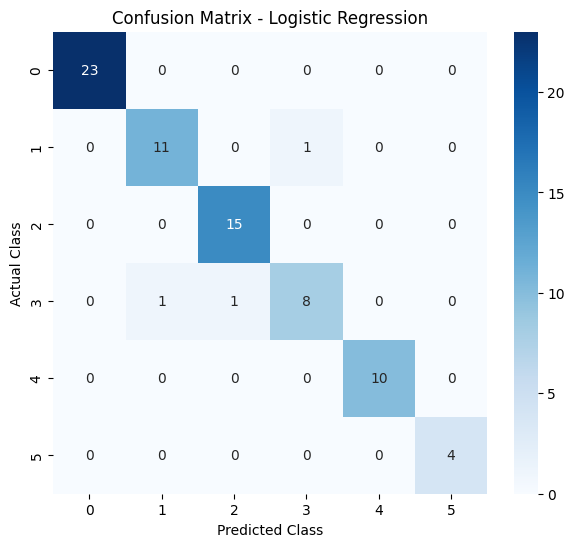

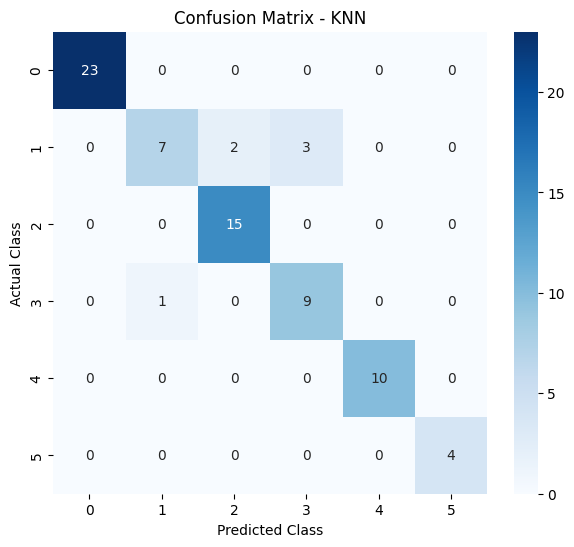

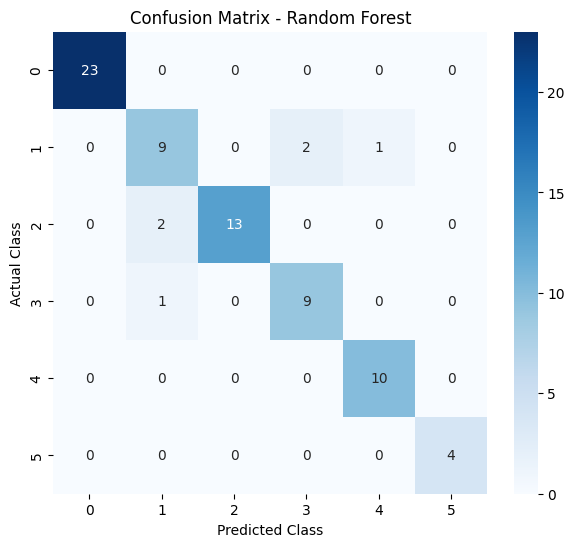

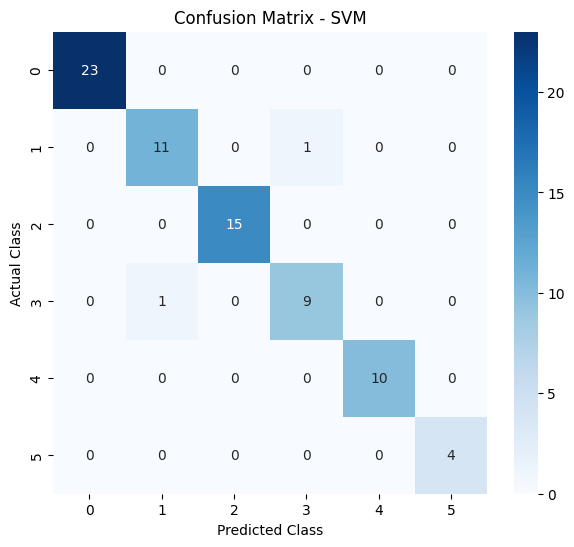

In [47]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model_predictions = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

for name, predictions in model_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.show()

In [48]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [49]:
y_test_bin = label_binarize(
    y_test,
    classes=[0, 1, 2, 3, 4, 5]
)

In [50]:
y_prob_lr = lr.predict_proba(X_test_scaled)

y_prob_knn = knn.predict_proba(X_test_scaled)

y_prob_rf = rf.predict_proba(X_test_scaled)

y_prob_svm = svm.predict_proba(X_test_scaled)

In [51]:
from sklearn.metrics import roc_auc_score

auc_lr = roc_auc_score(
    y_test_bin,
    y_prob_lr,
    multi_class='ovr',
    average='weighted'
)

auc_knn = roc_auc_score(
    y_test_bin,
    y_prob_knn,
    multi_class='ovr',
    average='weighted'
)

auc_rf = roc_auc_score(
    y_test_bin,
    y_prob_rf,
    multi_class='ovr',
    average='weighted'
)

auc_svm = roc_auc_score(
    y_test_bin,
    y_prob_svm,
    multi_class='ovr',
    average='weighted'
)

print("Logistic Regression AUC:", auc_lr)
print("KNN AUC:", auc_knn)
print("Random Forest AUC:", auc_rf)
print("SVM AUC:", auc_svm)

Logistic Regression AUC: 0.9976117921844753
KNN AUC: 0.9821429313574099
Random Forest AUC: 0.995981364428945
SVM AUC: 0.9971937663469922


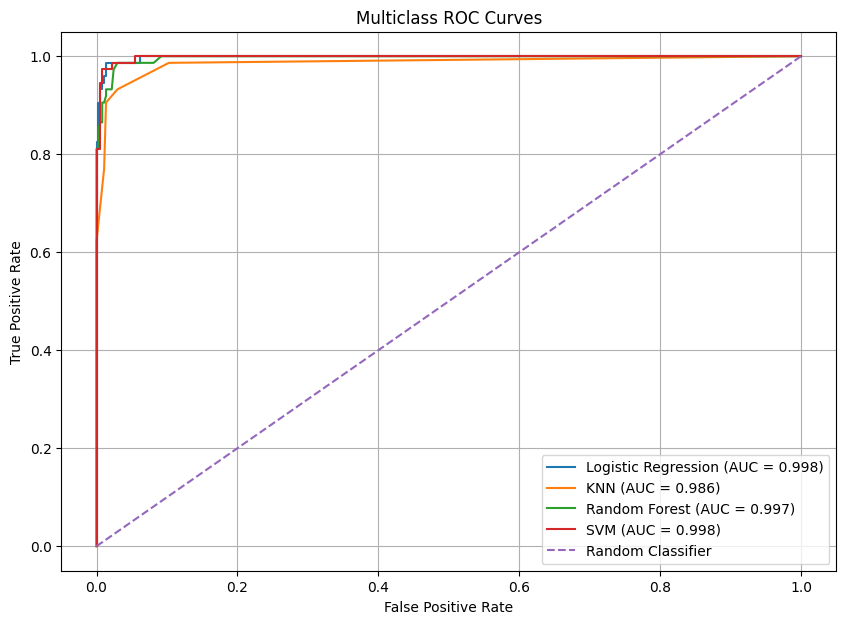

In [52]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

models_probabilities = {
    "Logistic Regression": y_prob_lr,
    "KNN": y_prob_knn,
    "Random Forest": y_prob_rf,
    "SVM": y_prob_svm
}

plt.figure(figsize=(10, 7))

for name, probabilities in models_probabilities.items():

    # Micro-average ROC
    fpr, tpr, thresholds = roc_curve(
        y_test_bin.ravel(),
        probabilities.ravel()
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend()
plt.grid()

plt.show()